## Natural Scene Image Classification using Machine Learning and Deep Learning

## Dataset Description

- **Dataset:** Intel Image Classification  
- **Total images:** ~17,000  
- **Image size:** 150 × 150 (RGB)  

- **Classes (6):**
  - buildings
  - forest
  - glacier
  - mountain
  - sea
  - street

- **Data split:**
  - Training set (~14,000 images)
  - Test set (~3,000 images)

### Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Data handling and visualization
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Traditional machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Data scaling and evaluation metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep learning models
import tensorflow as tf
from tensorflow.keras import layers, models  

### Exploratory Data Analysis

In [2]:
# Dataset Paths
train_path = "archive/seg_train/seg_train"
test_path = "archive/seg_test/seg_test"

#### Extract Class Labels

In [3]:
classes = [cls for cls in os.listdir(train_path) 
           if os.path.isdir(os.path.join(train_path, cls))]

print("Classes:", classes)

Classes: ['forest', 'buildings', 'glacier', 'street', 'mountain', 'sea']


#### Number of Images per Class

In [5]:
for cls in classes:
    class_path = os.path.join(train_path, cls)
    num_images = len(os.listdir(class_path))
    print(f"{cls}: {num_images}")

forest: 2271
buildings: 2191
glacier: 2404
street: 2382
mountain: 2512
sea: 2274


#### Class Distribution

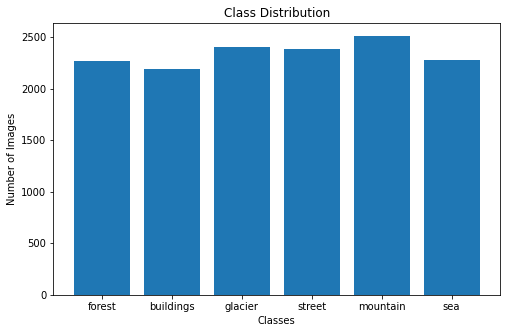

In [6]:
class_counts = []

for cls in classes:
    class_path = os.path.join(train_path, cls)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(8,5))
plt.bar(classes, class_counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

#### Sample Images from Each Class

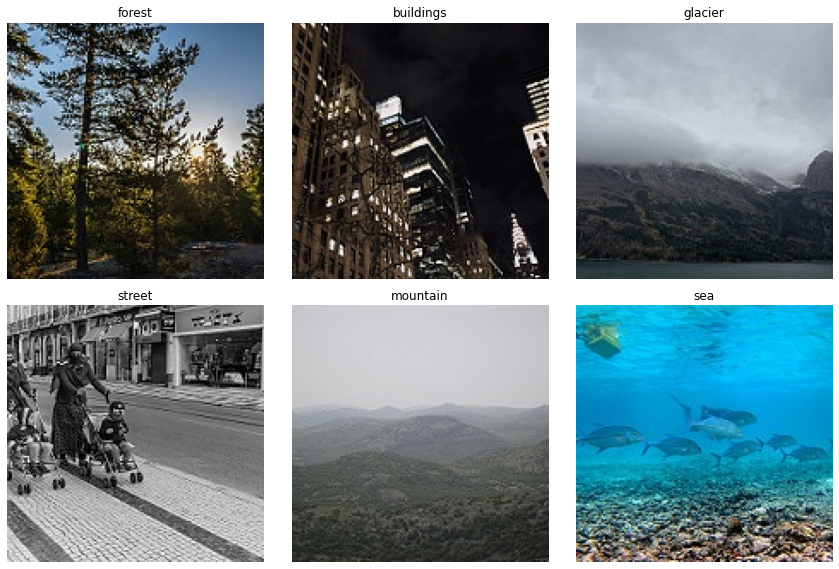

In [7]:
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Image Size and Shape Inspection

In [8]:
sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

sample_image = Image.open(sample_image_path)

print("Sample class:", sample_class)
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Image shape:", np.array(sample_image).shape)

Sample class: forest
Image size: (150, 150)
Image mode: RGB
Image shape: (150, 150, 3)


#### Check for Corrupted Images

In [9]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted_images.append(img_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


#### Train and Test Class Consistency

In [10]:
train_classes = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls))
])

test_classes = sorted([
    cls for cls in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, cls))
])

print("Train classes:", train_classes)
print("Test classes:", test_classes)
print("Classes match:", train_classes == test_classes)

Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Classes match: True


#### Pixel Value Range Inspection

In [11]:
sample_array = np.array(sample_image)

print("Minimum pixel value:", sample_array.min())
print("Maximum pixel value:", sample_array.max())

Minimum pixel value: 0
Maximum pixel value: 255


### Data Preprocessing

In [3]:
#normalize pixel values
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


#### Verify Data Generators

In [4]:
print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))
print("Test batches:", len(test_generator))
print("Class indices:", train_generator.class_indices)

Training batches: 351
Validation batches: 88
Test batches: 94
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


#### Prepare Data for Traditional Machine Learning Models

In [12]:
def load_images_for_ml(data_path, classes, image_size=(64, 64)):
    images = []
    labels = []

    for label, cls in enumerate(classes):
        class_path = os.path.join(data_path, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = load_img(img_path, target_size=image_size)
            img_array = img_to_array(img) / 255.0
            img_flattened = img_array.flatten()

            images.append(img_flattened)
            labels.append(label)

    return np.array(images), np.array(labels)

#### Load Flattened Image Data

In [17]:
X_train_ml, y_train_ml = load_images_for_ml(train_path, classes)
X_test_ml, y_test_ml = load_images_for_ml(test_path, classes)

print("X_train_ml shape:", X_train_ml.shape)
print("y_train_ml shape:", y_train_ml.shape)
print("X_test_ml shape:", X_test_ml.shape)
print("y_test_ml shape:", y_test_ml.shape)

X_train_ml shape: (14034, 12288)
y_train_ml shape: (14034,)
X_test_ml shape: (3000, 12288)
y_test_ml shape: (3000,)


### Model 1: Decision Tree

In [21]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train_ml, y_train_ml)

y_pred_dt = dt_model.predict(X_test_ml)

acc_dt = accuracy_score(y_test_ml, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.454


### Model 2: Random Forest

In [24]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_ml, y_train_ml)

y_pred_rf = rf_model.predict(X_test_ml)

acc_rf = accuracy_score(y_test_ml, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.5896666666666667


### Model 3: Convolutional Neural Network (CNN)

In [16]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

#### Compile and Train CNN Model

In [17]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
351/351 [==============================] - 134s 378ms/step - loss: 0.9767 - accuracy: 0.6211 - val_loss: 0.7676 - val_accuracy: 0.7204
Epoch 2/10
351/351 [==============================] - 150s 427ms/step - loss: 0.6598 - accuracy: 0.7623 - val_loss: 0.5892 - val_accuracy: 0.7974
Epoch 3/10
351/351 [==============================] - 158s 450ms/step - loss: 0.5065 - accuracy: 0.8165 - val_loss: 0.5329 - val_accuracy: 0.8142
Epoch 4/10
351/351 [==============================] - 175s 499ms/step - loss: 0.3885 - accuracy: 0.8596 - val_loss: 0.5984 - val_accuracy: 0.7971
Epoch 5/10
351/351 [==============================] - 177s 502ms/step - loss: 0.2982 - accuracy: 0.8915 - val_loss: 0.5456 - val_accuracy: 0.8178
Epoch 6/10
351/351 [==============================] - 198s 565ms/step - loss: 0.1920 - accuracy: 0.9315 - val_loss: 0.7239 - val_accuracy: 0.7989
Epoch 7/10
351/351 [==============================] - 188s 534ms/step - loss: 0.1287 - accuracy: 0.9557 - val_loss: 0.8445 -

#### CNN Training Curves

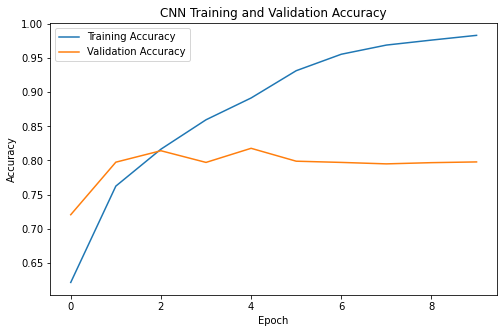

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()

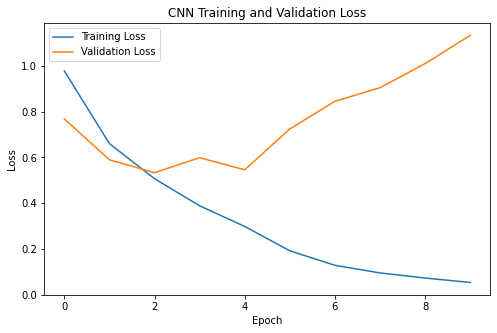

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()

### Model 4: CNN with Dropout

In [20]:
dropout_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

In [21]:
dropout_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dropout_history = dropout_cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
351/351 [==============================] - 160s 454ms/step - loss: 1.1150 - accuracy: 0.5604 - val_loss: 0.8426 - val_accuracy: 0.6762
Epoch 2/10
351/351 [==============================] - 167s 476ms/step - loss: 0.8036 - accuracy: 0.7045 - val_loss: 0.6407 - val_accuracy: 0.7750
Epoch 3/10
351/351 [==============================] - 167s 475ms/step - loss: 0.6822 - accuracy: 0.7583 - val_loss: 0.6073 - val_accuracy: 0.7718
Epoch 4/10
351/351 [==============================] - 157s 446ms/step - loss: 0.5942 - accuracy: 0.7934 - val_loss: 0.6106 - val_accuracy: 0.7842
Epoch 5/10
351/351 [==============================] - 186s 530ms/step - loss: 0.5156 - accuracy: 0.8111 - val_loss: 0.5723 - val_accuracy: 0.8063
Epoch 6/10
351/351 [==============================] - 189s 540ms/step - loss: 0.4206 - accuracy: 0.8503 - val_loss: 0.5306 - val_accuracy: 0.8156
Epoch 7/10
351/351 [==============================] - 155s 441ms/step - loss: 0.3489 - accuracy: 0.8729 - val_loss: 0.5510 -

### Model 5: CNN with Data Augmentation

In [7]:
# increase the diversity of the training data
augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

augmented_train_generator = augmented_train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

augmented_val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [8]:
aug_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(6, activation='softmax')
])

In [9]:
aug_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    augmented_train_generator,
    epochs=10,
    validation_data=augmented_val_generator
)

Epoch 1/10
351/351 [==============================] - 132s 374ms/step - loss: 1.0185 - accuracy: 0.6016 - val_loss: 0.8531 - val_accuracy: 0.6805
Epoch 2/10
351/351 [==============================] - 141s 401ms/step - loss: 0.7646 - accuracy: 0.7225 - val_loss: 0.6747 - val_accuracy: 0.7553
Epoch 3/10
351/351 [==============================] - 163s 465ms/step - loss: 0.6533 - accuracy: 0.7590 - val_loss: 0.5476 - val_accuracy: 0.8024
Epoch 4/10
351/351 [==============================] - 172s 491ms/step - loss: 0.5997 - accuracy: 0.7801 - val_loss: 0.5409 - val_accuracy: 0.8049
Epoch 5/10
351/351 [==============================] - 177s 505ms/step - loss: 0.5430 - accuracy: 0.8036 - val_loss: 0.4769 - val_accuracy: 0.8338
Epoch 6/10
351/351 [==============================] - 379s 1s/step - loss: 0.5124 - accuracy: 0.8153 - val_loss: 0.4714 - val_accuracy: 0.8374
Epoch 7/10
351/351 [==============================] - 328s 934ms/step - loss: 0.4819 - accuracy: 0.8252 - val_loss: 0.5085 - va

### Model 6: Final CNN with Dropout and Data Augmentation

#### Data Augmentation

In [17]:
final_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(6, activation='softmax')
])

In [18]:
final_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_history = final_cnn_model.fit(
    augmented_train_generator,
    epochs=20,
    validation_data=augmented_val_generator
)

Epoch 1/20
351/351 [==============================] - 138s 391ms/step - loss: 1.2272 - accuracy: 0.5164 - val_loss: 0.9364 - val_accuracy: 0.6544
Epoch 2/20
351/351 [==============================] - 140s 398ms/step - loss: 0.9518 - accuracy: 0.6419 - val_loss: 0.7139 - val_accuracy: 0.7529
Epoch 3/20
351/351 [==============================] - 140s 400ms/step - loss: 0.8345 - accuracy: 0.6914 - val_loss: 0.7273 - val_accuracy: 0.7496
Epoch 4/20
351/351 [==============================] - 145s 412ms/step - loss: 0.7457 - accuracy: 0.7291 - val_loss: 0.6065 - val_accuracy: 0.7867
Epoch 5/20
351/351 [==============================] - 144s 411ms/step - loss: 0.6957 - accuracy: 0.7517 - val_loss: 0.6158 - val_accuracy: 0.7710
Epoch 6/20
351/351 [==============================] - 136s 388ms/step - loss: 0.6656 - accuracy: 0.7583 - val_loss: 0.5573 - val_accuracy: 0.8128
Epoch 7/20
351/351 [==============================] - 134s 382ms/step - loss: 0.6180 - accuracy: 0.7782 - val_loss: 0.4934 -

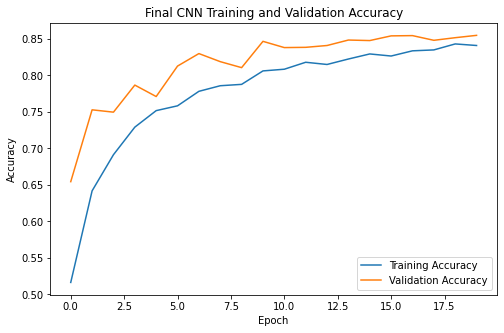

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(final_history.history['accuracy'], label='Training Accuracy')
plt.plot(final_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final CNN Training and Validation Accuracy')
plt.legend()
plt.show()

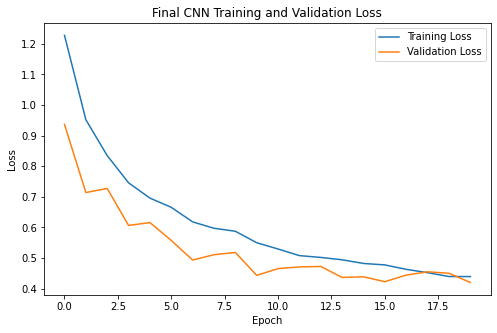

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(final_history.history['loss'], label='Training Loss')
plt.plot(final_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final CNN Training and Validation Loss')
plt.legend()
plt.show()

### Final Comparison of Model Accuracy

<div style="width:90%; margin-left:0;">

<table style="width:100%; font-size:20px; border-collapse:collapse;">
<thead>
<tr>
<th style="text-align:left; padding:10px; border-bottom:2px solid black;">Model</th>
<th style="text-align:left; padding:10px; border-bottom:2px solid black;">Accuracy</th>
</tr>
</thead>

<tbody>
<tr>
<td style="text-align:left; padding:10px;">Decision Tree</td>
<td style="text-align:left; padding:10px;">0.454</td>
</tr>

<tr>
<td style="text-align:left; padding:10px;">Random Forest</td>
<td style="text-align:left; padding:10px;">0.589</td>
</tr>

<tr>
<td style="text-align:left; padding:10px;">Basic CNN</td>
<td style="text-align:left; padding:10px;">0.797</td>
</tr>

<tr>
<td style="text-align:left; padding:10px;">CNN with Dropout</td>
<td style="text-align:left; padding:10px;">0.818</td>
</tr>

<tr>
<td style="text-align:left; padding:10px;">CNN with Data Augmentation</td>
<td style="text-align:left; padding:10px;">0.846</td>
</tr>

<tr>
<td style="text-align:left; padding:10px;"><b>Final CNN (Dropout + Data Augmentation)</b></td>
<td style="text-align:left; padding:10px;"><b>0.854</b></td>
</tr>
</tbody>
</table>

</div>

### Evaluation Metrics

In [21]:
test_generator.reset()

y_true = test_generator.classes

y_pred_probs = final_cnn_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

94/94 [==============================] - 12s 125ms/step


In [22]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.82      0.88      0.85       437
      forest       0.97      0.97      0.97       474
     glacier       0.79      0.82      0.80       553
    mountain       0.79      0.78      0.78       525
         sea       0.86      0.86      0.86       510
      street       0.90      0.82      0.86       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.85      3000
weighted avg       0.85      0.85      0.85      3000



### Confusion Matrix

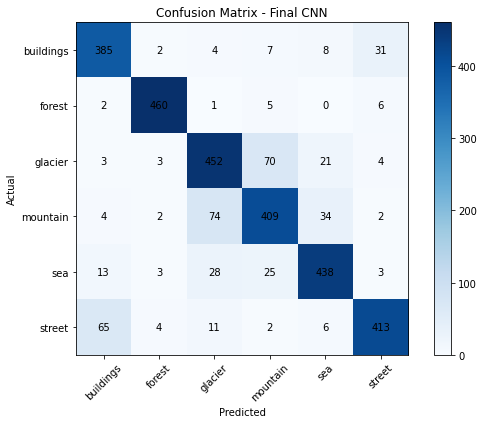

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final CNN")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()